**NB - Binary Classification**

In [1]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv('C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 4 - Naive Bayes/diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.shape

(768, 9)

In [4]:
# Descriptive statistics
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# Detect missing values
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

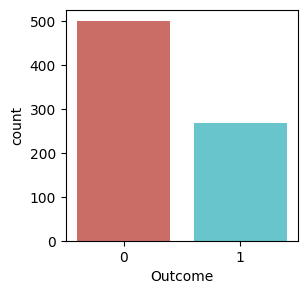

<Figure size 640x480 with 0 Axes>

In [6]:
# class distribution
plt.figure(figsize = (3,3))
data['Outcome'].value_counts()
sns.countplot(x = 'Outcome', data = data, palette = 'hls')
plt.show()
plt.savefig('Outcome')

**NOTE:** Required preprocessing must be done as per the noise detection

In [7]:
# Variable assingment
x = data.drop('Outcome', axis = 1)
y = data['Outcome']

In [8]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [9]:
# Data split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 42)

In [10]:
x_test[0:5]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
668,6,98,58,33,190,34.0,0.430,43
324,2,112,75,32,0,35.7,0.148,21
624,2,108,64,0,0,30.8,0.158,21
690,8,107,80,0,0,24.6,0.856,34
473,7,136,90,0,0,29.9,0.210,50


In [11]:
y_test.head()

668    0
324    0
624    0
690    0
473    0
Name: Outcome, dtype: int64

**MultinomialNB**

In [12]:
mnb = MultinomialNB()
mnb.fit(x_train, y_train)
y_p = mnb.predict(x_test)
acc = accuracy_score(y_test, y_p)*100
print("NB - Accuracy: {:.3f}.".format(acc))
print("\nClassification Report")
print(classification_report(y_test, y_p))

NB - Accuracy: 66.234.

Classification Report
              precision    recall  f1-score   support

           0       0.73      0.75      0.74        99
           1       0.53      0.51      0.52        55

    accuracy                           0.66       154
   macro avg       0.63      0.63      0.63       154
weighted avg       0.66      0.66      0.66       154



In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_p)
print(cm)

[[74 25]
 [27 28]]


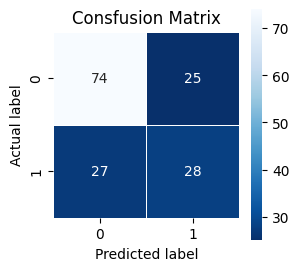

In [14]:
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'Blues_r');
plt.xlabel('Predicted label');
plt.ylabel('Actual label');
plt.title("Consfusion Matrix", size = 12);

**GaussianNB**

In [15]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train, y_train)
y_p = gnb.predict(x_test)
acc = accuracy_score(y_test, y_p)*100
print("GNB - Accuracy: {:.3f}.".format(acc))
print("\nClassification Report")
print(classification_report(y_test, y_p))

GNB - Accuracy: 76.623.

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [16]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_p)
print(cm)

[[79 20]
 [16 39]]


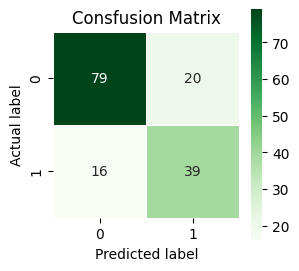

In [ ]:
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot = True, linewidths = 0.5, square = True, cmap = 'Greens')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title("Confusion Matrix", size = 12)

**Class balancing**

In [18]:
# %pip install imbalanced-learn

Counter({0: 401, 1: 401})


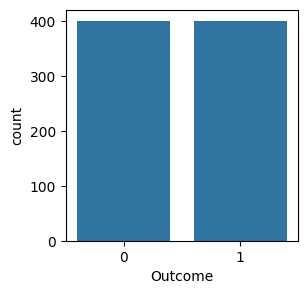

In [19]:
from collections import Counter
from imblearn.over_sampling import SMOTE
x_train_b, y_train_b = SMOTE().fit_resample(x_train, y_train)

plt.subplots(figsize = (3,3))
sns.countplot(x = y_train_b)
print(Counter(y_train_b))

**MultinomialNB**

In [20]:
mnb_b = MultinomialNB()
mnb_b.fit(x_train_b, y_train_b)
y_pred_b = mnb_b.predict(x_test)
acc_1 = accuracy_score(y_test, y_pred_b)*100
print("NB - Accuracy: {:.3f}.".format(acc_1))
print("\nClassification Report")
print(classification_report(y_test, y_pred_b))

NB - Accuracy: 68.182.

Classification Report
              precision    recall  f1-score   support

           0       0.76      0.75      0.75        99
           1       0.55      0.56      0.56        55

    accuracy                           0.68       154
   macro avg       0.65      0.66      0.65       154
weighted avg       0.68      0.68      0.68       154



In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_b)
print(cm)

[[74 25]
 [24 31]]


Text(0.5, 1.0, 'Consfusion Matrix')

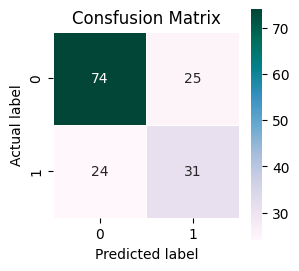

In [22]:
plt.figure(figsize=(3,3))
sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'PuBuGn')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title("Consfusion Matrix", size = 12)

**GaussianNB**

In [23]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(x_train_b, y_train_b)
y_pred_b = gnb.predict(x_test)
acc = accuracy_score(y_test, y_pred_b)*100
print("GNB - Accuracy: {:.3f}.".format(acc))
print("\nClassification Report")
print(classification_report(y_test, y_pred_b))

GNB - Accuracy: 74.026.

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.73      0.78        99
           1       0.61      0.76      0.68        55

    accuracy                           0.74       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.76      0.74      0.75       154



In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_b)
print(cm)

[[72 27]
 [13 42]]


Text(0.5, 1.0, 'Confusion Matrix')

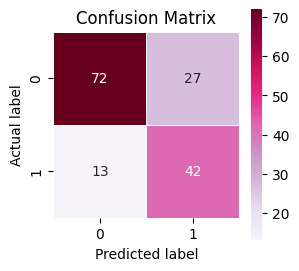

In [25]:
plt.figure(figsize = (3,3))
sns.heatmap(cm, annot=True, linewidths=.5, square = True, cmap = 'PuRd')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title("Confusion Matrix", size = 12)

Among the MultinomialNB and GaussianNB models, GaussianNB model is more suitable for classification problems using structured TV. MultinomialNB model is more suitable for text classification problems.

No Hyperparameter tuning is required for both MultinomialNB and GaussianNB as they already smoothed models. 

The performances of the models built using balanced dataset are acceptable with very amount of less overfitting (if any). 

Hence, a Cross-Validation can be done to further validate the models.Cross-Validation techniques will be discuss in future sessions.

**Stratified KFold**

* Stratified K-Folds cross-validation is the most suitable technique for classification models and to validate the NB model.

* Provides train/test indices to split data in train/test sets.

* This cross-validation object is a variation of KFold that returns stratified folds. The folds are made by preserving the percentage of samples for each class.

* If your goal is to build a model that performs well on all classes, then balancing is often necessary.

In [26]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

accuracy_skcv = cross_val_score(gnb, x_train_b, y_train_b, cv = skf, scoring = 'accuracy')
print(accuracy_skcv)
print("Average Accuracy after Stratified K-Fold CV: ", np.mean(accuracy_skcv))

[0.70807453 0.71428571 0.7875     0.6875     0.66875   ]
Average Accuracy after Stratified K-Fold CV:  0.713222049689441


**Repeated KFold**

In [27]:
from sklearn.model_selection import RepeatedKFold
rkf = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = 42)

accuracy_rkcv = cross_val_score(gnb, x_train_b, y_train_b, cv = rkf, scoring = 'accuracy')
print(accuracy_rkcv)
print("Average Accuracy after Repeated K-Fold CV: ", np.mean(accuracy_rkcv))

[0.72049689 0.72049689 0.75       0.66875    0.75       0.70186335
 0.71428571 0.7625     0.65625    0.68125    0.73913043 0.73913043
 0.7125     0.74375    0.6625     0.72049689 0.71428571 0.68125
 0.7125     0.75625    0.67701863 0.76397516 0.6875     0.7
 0.75      ]
Average Accuracy after Repeated K-Fold CV:  0.7154472049689441
